<a href="https://colab.research.google.com/github/Raksh2023/Ada-lab-assignments/blob/main/NN_1(2301201087).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import os

# disable GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# reduce threading
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

In [3]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [4]:
tf.config.set_visible_devices([], 'GPU')

In [5]:
import platform
platform.processor()

'x86_64'

Q1. Explain the role of weights in a neuron

Ans. Weights in an ANN are numerical values associated with the connections between neurons (or nodes) across different layers of the network. Each connection from one neuron to another has an associated weight that signifies the strength and direction (positive or negative) of the influence one neuron has on another. When an input signal passes through the network, it gets multiplied by these weights, which cumulatively determine the final output of the network.

The weights in an ANN are crucial because they directly influence the signals transmitted across the network and ultimately determine the network's output. During the training phase, the ANN learns by iteratively adjusting these weights to predict the correct output for a given set of inputs. The set of weights in the network encapsulates what the network has learned from the training data, effectively encoding the knowledge necessary for making predictions or decisions.

Key roles of weights include:
Signal Scaling: Each input is multiplied by a weight. High weights mean the input is crucial, while weights near zero suggest the input is ignored.
Determining Importance: Weights identify which input features are more significant for the task, such as prioritizing specific pixels for image recognition.
Learning Capability: During training (via backpropagation), the model adjusts these numerical values to minimize the difference between predicted and actual outputs.
Defining Connections: They define the relationship between layers, allowing the network to build complex models from simple inputs.

Q2. What is an activation function?

Ans. Activation functions are an integral building block of neural networks that enable them to learn complex patterns in data. They transform the input signal of a node in a neural network into an output signal that is then passed on to the next layer. Without activation functions, neural networks would be restricted to modeling only linear relationships between inputs and outputs.

Activation functions introduce non-linearities, allowing neural networks to learn highly complex mappings between inputs and outputs.

Choosing the right activation function is crucial for training neural networks that generalize well and provide accurate predictions. In this post, we will provide an overview of the most common activation functions, their roles, and how to select suitable activation functions for different use cases.

Without activation functions, neural networks would just consist of linear operations like matrix multiplication. All layers would perform linear transformations of the input, and no non-linearities would be introduced.

f neural networks had no activation functions, they would fail to learn the complex non-linear patterns that exist in real-world data.

Activation functions enable neural networks to learn these non-linear relationships by introducing non-linear behaviors through activation functions. This greatly increases the flexibility and power of neural networks to model complex and nuanced data.



Q3. Define probability distribution in ML context.

Ans. Probability distributions play a vital role in the field of machine learning, providing the mathematical foundation for many algorithms and models. They help in understanding data, making predictions, and estimating uncertainty. In this blog, we will explore the concept of probability distributions, their importance in machine learning, and some common types of distributions used in the field.

A probability distribution shows how the values of a random variable are spread out. It tells us the likelihood of different outcomes. There are two main types of probability distributions:

Discrete Probability Distributions: These are used for variables that can take on a countable number of values.

Continuous Probability Distributions: These are used for variables that can take on any value within a range.

Key Aspects of Probability Distributions in ML

Purpose: Used to model, predict, and analyze the underlying patterns of data.

Types of Distributions:
Normal Distribution (Gaussian): Commonly used for continuous features, often modeled using mean
(μ) and standard deviation (σ)

Bernoulli/Binomial Distribution: Used for binary classification (e.g., success/failure, 0 or 1).
Uniform Distribution: Assumes every outcome is equally likely.
Poisson Distribution: Models the number of independent events occurring within a specific interval.
Beta/Dirichlet Distribution: Used in Bayesian inference as prior distributions.

Key Functions:
Probability Mass Function (PMF): Used for discrete random variables.
Probability Density Function (PDF): Defines the likelihood of a continuous random variable falling within a range.

Contextual Applications:
Modeling Uncertainty: Assessing risks and confidence in predictions.
Generative Modeling: Learning the underlying distribution of data to generate new samples.
Parameter Estimation: Using observed data to estimate the parameters of a distribution (e.g., in Maximum Likelihood Estimation).

Types of Probabilities:
Joint Probability: For two or more random variables.
Marginal Probability: Probability distribution of a subset of variables.
Conditional Probability: The probability of an event given that another event has occurred, foundational for classifiers.

In essence, these distributions are crucial for understanding data,, allowing models to move beyond simple point estimates to understanding the probability structure of the data itself,

Q4. What is gradient in optimization?

Ans. Gradient optimization (or gradient-based optimization) is an iterative mathematical technique that finds the local minimum or maximum of a function by calculating its gradient—the vector of partial derivatives. In machine learning, it is used to minimize a loss function by updating parameters (weights) in the opposite direction of the slope.

Key details about gradient optimization include:
Core Principle: It relies on calculus to determine the steepest slope and moves in that direction to find an optimum.
Gradient Descent vs. Ascent: Gradient descent minimizes a function (e.g., loss), while gradient ascent maximizes a function (e.g., reward).

Key Components:
Cost Function: Measures the error of a model.
Gradient: The derivative of the cost function with respect to parameters, indicating the slope.
Learning Rate (α): A hyperparameter that determines the size of the step taken toward the minimum.
Variants: Common methods include Batch Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-Batch Gradient Descent.
Improvements: Techniques like Momentum help accelerate convergence by accounting for previous gradients.


Q5. Create a project using logistic regression with tensor?

Ans. Student Placement Prediction System (TensorFlow Logistic Regression)

Project idea: Build a system that predicts whether a student will get placed or not based on academic and skill-related features.

Problem statement:
Given student attributes:
CGPA,
Internship experience,
Projects count,
Technical skills score,
Communication score,
Aptitude score

Predict Placement (0 = No, 1 = Yes)


In [14]:
!pip install pandas scikit-learn joblib

In [15]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [16]:
class LogisticRegressionTF:
    def __init__(self, input_dim, lr=0.01):
        self.W = tf.Variable(tf.random.normal([input_dim,1]))
        self.b = tf.Variable(tf.zeros([1]))
        self.lr = lr

    def sigmoid(self,x):
        return 1/(1+tf.exp(-x))

    def predict_proba(self,X):
        logits = tf.matmul(X,self.W)+self.b
        return self.sigmoid(logits)

    def loss(self,y_true,y_pred):
        return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true,y_pred))

    def train_step(self,X,y):
        with tf.GradientTape() as tape:
            y_pred = self.predict_proba(X)
            loss = self.loss(y,y_pred)
        grads = tape.gradient(loss,[self.W,self.b])
        self.W.assign_sub(self.lr*grads[0])
        self.b.assign_sub(self.lr*grads[1])
        return loss

In [17]:
df = pd.read_csv("placement_data.csv")
df.head()

,CGPA,Internships,Projects,TechSkill,CommSkill,Aptitude,Placed
0,6.872701,0,4,8,6,8,1
1,9.753572,3,3,9,9,5,1
2,8.659970,3,2,5,9,4,1
3,7.993292,1,1,9,6,7,1
4,5.780093,2,1,7,7,7,0


In [18]:
X = df.drop("Placed",axis=1).values
y = df["Placed"].values.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

X_train = tf.constant(X_train,dtype=tf.float32)
y_train = tf.constant(y_train,dtype=tf.float32)

In [19]:
model = LogisticRegressionTF(input_dim=X_train.shape[1],lr=0.05)

loss_history = []

for epoch in range(300):
    loss = model.train_step(X_train,y_train)
    loss_history.append(loss.numpy())

    if epoch%50==0:
        print("Epoch:",epoch,"Loss:",loss.numpy())

print("Training done")

Epoch: 0 Loss: 0.57517105
Epoch: 50 Loss: 0.39120272
Epoch: 100 Loss: 0.29846886
Epoch: 150 Loss: 0.24938615
Epoch: 200 Loss: 0.22125445
Epoch: 250 Loss: 0.2036183
Training done


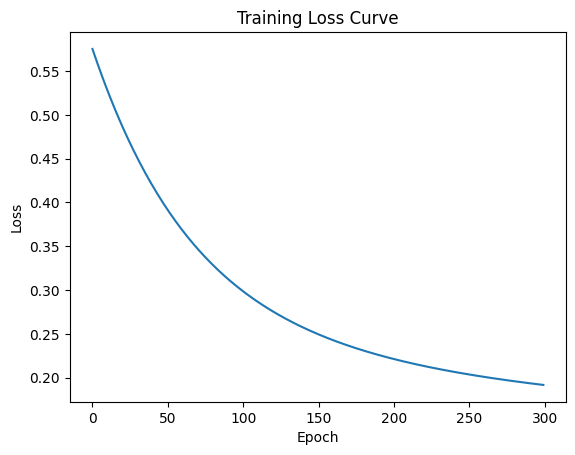

In [20]:
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [21]:
X_test_tf = tf.constant(X_test,dtype=tf.float32)

prob = model.predict_proba(X_test_tf).numpy()
pred = (prob>0.5).astype(int)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9666666666666667


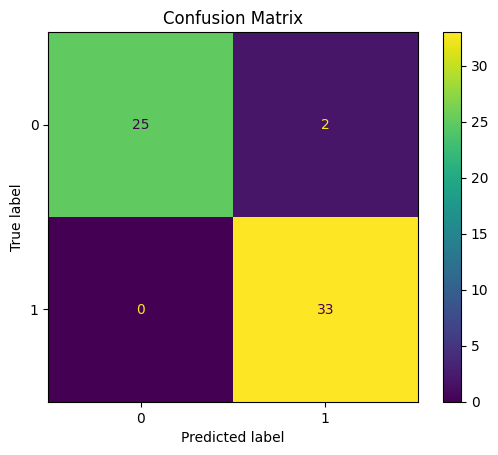

In [22]:
cm = confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

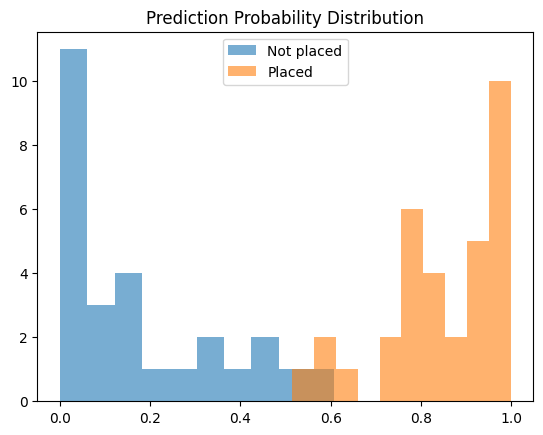

In [23]:
plt.hist(prob[y_test==0],alpha=0.6,label="Not placed")
plt.hist(prob[y_test==1],alpha=0.6,label="Placed")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.show()